# 06 Validierung & Sensitivitätsanalyse

**PA1 ZHAW IUNR** | Bächler, Hofstetter, Reichlin | Betreuer: Patrick Laube

1. **Standort-Trefferquote (Hit Rate)** – Reale Standorte vs. geeignete Fläche
2. **Mann-Whitney U Test** – Standort-Werte vs. zufällige Constraint-Pixel
3. **Kruskal-Wallis** – Verteilung nach Status-Gruppen
4. **OAT-Sensitivitätsanalyse** – 10 Kriterien ±20%

**Input:**
```
outputs/suitability_wlc.tif
outputs/suitability_postprocessed.tif
data/raw/validation/alpine_pv_plants.csv
data/processed/constraints/constraint_mask_s2.tif
data/processed/criteria/f01_globalstrahlung.tif
data/processed/criteria/f02_wintereinstrahlung.tif
data/processed/criteria/f03_hangneigung.tif
data/processed/criteria/f04_exposition.tif
data/processed/criteria/f05_hoehenlage.tif
data/processed/criteria/f06_schneebedeckung.tif
data/processed/criteria/f07_netzanschluss.tif
data/processed/criteria/f08_strasse.tif
data/processed/criteria/f09_infrastruktur.tif
data/processed/criteria/f10_sichtbarkeit.tif
```

**Status-Gewichtung:**
- connected to grid: 1.0
- under construction: 0.8
- in planning: 0.6
- deferred: 0.3
- discarded: 0.0


## 1. Setup

In [5]:
from pathlib import Path
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from shapely.geometry import Point
from pyproj import Transformer
from scipy.stats import mannwhitneyu, kruskal, spearmanr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})

RAW = Path("../projekt_final/data/raw")
PROC = Path("../projekt_final/data/processed")
OUT_R = Path("../projekt_final/outputs")
OUT_F = OUT_R / "figures"
OUT_T = OUT_R / "tables"
for d in [OUT_F, OUT_T]:
    d.mkdir(parents=True, exist_ok=True)

CRS = "EPSG:2056"
RES = 25
NODATA = -9999.0

STATUS_WEIGHTS = {
    "connected to grid": 1.0,
    "under construction": 0.8,
    "in planning": 0.6,
    "deferred": 0.3,
    "discarded": 0.0,
}

STATUS_ORDER = [
    "connected to grid",
    "under construction",
    "in planning",
    "deferred",
    "discarded",
]

STATUS_COLORS = {
    "connected to grid": "#2ecc71",
    "under construction": "#3498db",
    "in planning": "#e67e22",
    "deferred": "#f1c40f",
    "discarded": "#e74c3c",
}

print("Setup OK")
print(f"Status-Gewichte: {STATUS_WEIGHTS}")


Setup OK
Status-Gewichte: {'connected to grid': 1.0, 'under construction': 0.8, 'in planning': 0.6, 'deferred': 0.3, 'discarded': 0.0}


## 2. Daten laden

In [6]:
# Eignungskarte (WLC)
suit_path = OUT_R / "suitability_wlc.tif"
if not suit_path.exists():
    suit_path = OUT_R / "suitability_postprocessed.tif"
with rasterio.open(suit_path) as src:
    suit = src.read(1)
    suit_tf = src.transform
    suit_profile = src.profile.copy()
    height, width = suit.shape

# Constraint-Maske
with rasterio.open(PROC / "constraints/constraint_mask_s2.tif") as src:
    cmask = src.read(1)

valid = (cmask == 1)
print(f"Eignungskarte: {suit_path.name} | {width}×{height}")
print(f"Geeignete Pixel: {valid.sum():,} ({valid.sum()*RES*RES/1e6:.0f} km²)")

Eignungskarte: suitability_wlc.tif | 5641×4010
Geeignete Pixel: 626,229 (391 km²)


In [7]:
# Standortdaten laden und Eignungswerte aus dem WLC extrahieren (5×5 Maximum)
df_plants = pd.read_csv(RAW / 'validation/alpine_pv_plants.csv')
tf_proj = Transformer.from_crs('EPSG:4326', CRS, always_xy=True)
df_plants['E'], df_plants['N'] = tf_proj.transform(df_plants['lon'].values, df_plants['lat'].values)
df_plants['weight'] = df_plants['status'].map(STATUS_WEIGHTS)
df_plants['geometry'] = [Point(e, n) for e, n in zip(df_plants['E'], df_plants['N'])]
gdf_plants = gpd.GeoDataFrame(df_plants, geometry='geometry', crs=CRS)

suit_values = []
in_constraint = []
for _, r in gdf_plants.iterrows():
    col = int((r.E - suit_tf.c) / suit_tf.a)
    row = int((r.N - suit_tf.f) / suit_tf.e)
    if 0 <= row < height and 0 <= col < width:
        r_min, r_max = max(0, row - 2), min(height, row + 3)
        c_min, c_max = max(0, col - 2), min(width, col + 3)
        window = suit[r_min:r_max, c_min:c_max]
        suit_values.append(window.max())
        in_constraint.append('✓' if cmask[row, col] == 1 else '✗')
    else:
        suit_values.append(np.nan)
        in_constraint.append('OOB')

gdf_plants['suit_value'] = suit_values
gdf_plants['in_constraint'] = in_constraint
df_location = gdf_plants[['name', 'status', 'weight', 'capacity_kw', 'annual_yield_gwh', 'specific_yield_kwh_kwp', 'suit_value', 'in_constraint']].copy()
df_location.columns = ['Name', 'Status', 'Gewicht', 'Leistung [kW]', 'Produktion [GWh/a]', 'Spezifisch [kWh/kWp]', 'Eignungswert', 'In Constraint']
print(f'Standorte geladen: {len(gdf_plants)}')
print(df_location[['Name', 'Status', 'Gewicht', 'Eignungswert', 'In Constraint']].to_string(index=False))

df_location.to_csv(OUT_T / 'validation_point_detail.csv', index=False)



Standorte geladen: 22
                        Name             Status  Gewicht  Eignungswert In Constraint
               Albigna Solar  connected to grid      1.0  -9999.000000             ✗
               Bernina Solar        in planning      0.6  -9999.000000             ✗
                Caischavedra  connected to grid      1.0  -9999.000000             ✗
                 Heinzenberg          discarded      0.0      0.713406             ✗
                 Lago di Lei  connected to grid      1.0  -9999.000000             ✗
                Madrisasolar under construction      0.8      0.836185             ✓
                   NalpSolar under construction      0.8  -9999.000000             ✗
                Nandro Solar          discarded      0.0  -9999.000000             ✗
       Ovra Solara Camplauns          discarded      0.0      0.819308             ✓
         Ovra Solara Magriel        in planning      0.6      0.795918             ✗
           Ovra Solara Rueun          disca

## 3. Standort-Trefferquote (Hit Rate)

Positiv sind realisierte und geplante Standorte (connected, under construction, in planning).
Hit Rate = Anzahl Standorte mit Eignungswert > 0 / Total positiv.


Hit Rate positiv: 5/13 (38.5 %)

Hit Rate pro Status:
            Status  Total  Treffer  HitRate
 connected to grid      4        1     25.0
under construction      4        1     25.0
       in planning      5        3     60.0
          deferred      3        0      0.0
         discarded      6        3     50.0
Fehlende positive Standorte: 8
 - 0 (außerhalb Constraint-Maske)
 - 1 (außerhalb Constraint-Maske)
 - 2 (außerhalb Constraint-Maske)
 - 4 (außerhalb Constraint-Maske)
 - 6 (außerhalb Constraint-Maske)
 - 11 (außerhalb Constraint-Maske)
 - 16 (außerhalb Constraint-Maske)
 - 18 (außerhalb Constraint-Maske)


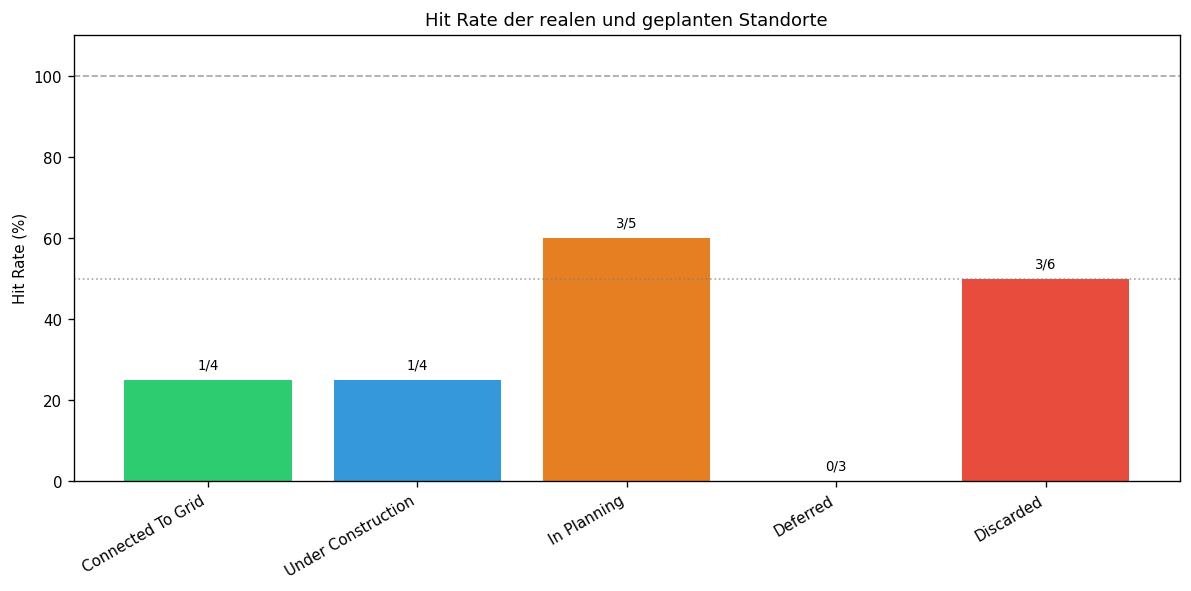

In [8]:
positive_statuses = ['connected to grid', 'under construction', 'in planning']
positive = gdf_plants[gdf_plants['status'].isin(positive_statuses)].copy()
positive['hit'] = positive['suit_value'] > 0
hit_count = int(positive['hit'].sum())
hit_rate = hit_count / len(positive) * 100
print(f'Hit Rate positiv: {hit_count}/{len(positive)} ({hit_rate:.1f} %)')

status_stats = []
for status in STATUS_ORDER:
    group = gdf_plants[gdf_plants['status'] == status]
    hits = int((group['suit_value'] > 0).sum())
    status_stats.append({'Status': status, 'Total': len(group), 'Treffer': hits, 'HitRate': hits / len(group) * 100 if len(group) else np.nan})
df_hit = pd.DataFrame(status_stats)
print('\nHit Rate pro Status:')
print(df_hit.to_string(index=False))

missing = []
for _, r in positive.loc[~positive['hit']].iterrows():
    if r['in_constraint'] == 'OOB':
        reason = 'OOB'
    elif r['in_constraint'] != '✓':
        reason = 'außerhalb Constraint-Maske'
    else:
        reason = 'suit_value <= 0'
    missing.append(f'{r.name} ({reason})')
if missing:
    print(f'Fehlende positive Standorte: {len(missing)}')
    for item in missing:
        print(' -', item)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_hit['Status'], df_hit['HitRate'], color=[STATUS_COLORS[s] for s in df_hit['Status']])
for bar, count, total in zip(bars, df_hit['Treffer'], df_hit['Total']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, f'{count}/{total}', ha='center', va='bottom', fontsize=8)
ax.set_ylim(0, 110)
ax.axhline(100, color='gray', ls='--', linewidth=1, alpha=0.7)
ax.axhline(50, color='gray', ls=':', linewidth=1, alpha=0.7)
ax.set_ylabel('Hit Rate (%)')
ax.set_title('Hit Rate der realen und geplanten Standorte')
ax.set_xticklabels([s.replace('_', ' ').title() for s in df_hit['Status']], rotation=30, ha='right')
plt.tight_layout()
fig.savefig(OUT_F / 'validation_hitrate.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Mann-Whitney U Test

Vergleich der realen Standort-Werte gegen zufällige Punkte aus der Constraint-Maske.
Alternative Hypothese: Standort-Werte sind höher als zufällige Werte.


Mann-Whitney U (Site vs. Zufall): U=4518.0, p=1, r=-0.148
Positiv-Standorte vs. Zufall: U=2610.0, p=0.9999, r=-0.117


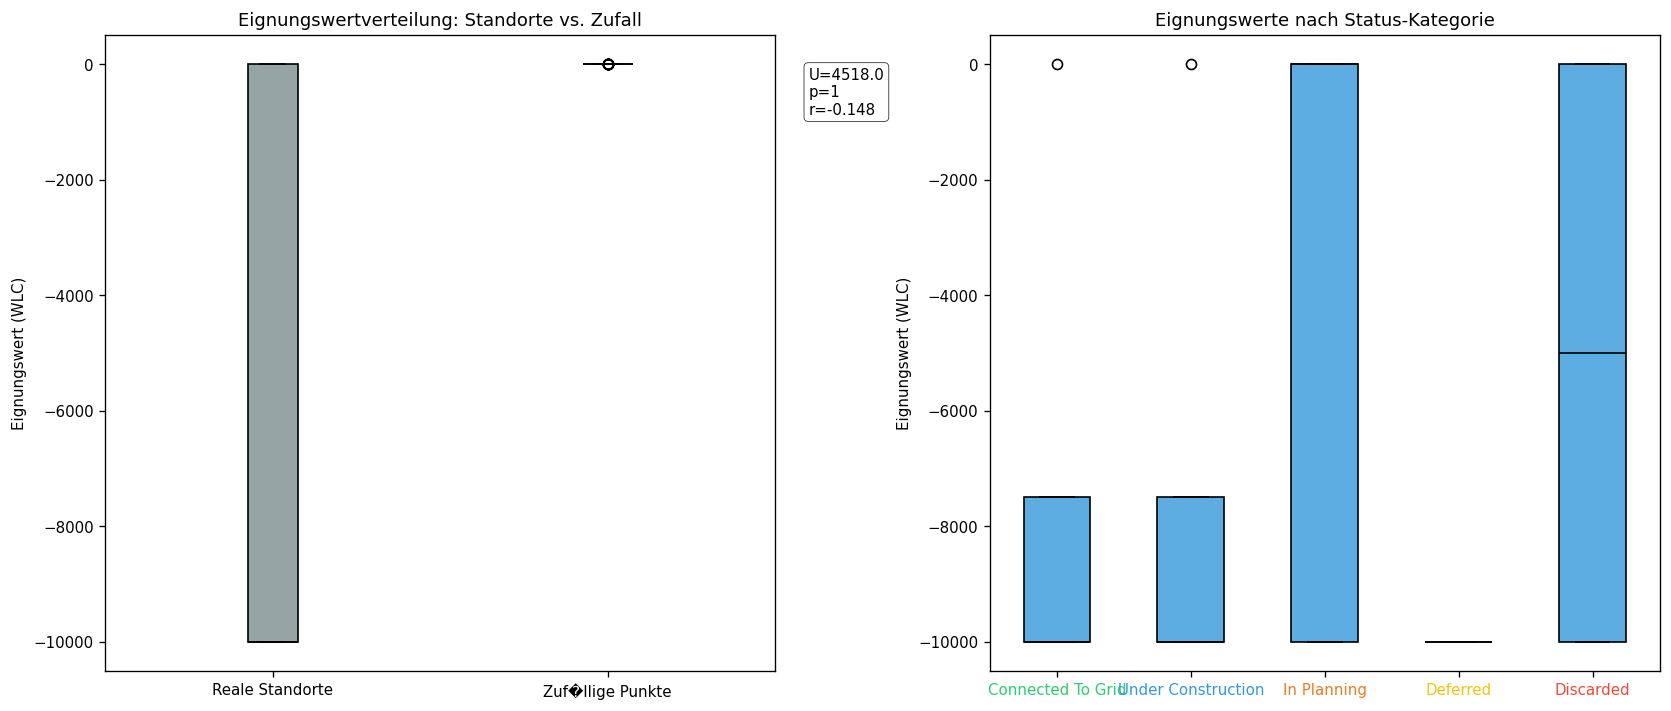

In [9]:
np.random.seed(42)
site_values = gdf_plants['suit_value'].fillna(0).values
valid_values = suit[valid].ravel()
sample_size = min(1000, len(valid_values))
random_values = np.random.choice(valid_values, size=sample_size, replace=False)
u_stat, p_value = mannwhitneyu(site_values, random_values, alternative='greater')
n1, n2 = len(site_values), len(random_values)
mu = n1 * n2 / 2
sigma = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
z_score = (u_stat - mu) / sigma
effect_size = z_score / np.sqrt(n1 + n2)
print(f'Mann-Whitney U (Site vs. Zufall): U={u_stat:.1f}, p={p_value:.4g}, r={effect_size:.3f}')

positive = gdf_plants[gdf_plants['status'].isin(['connected to grid', 'under construction', 'in planning'])]
positive_values = positive['suit_value'].fillna(0).values
u_pos, p_pos = mannwhitneyu(positive_values, random_values, alternative='greater')
mu_pos = len(positive_values) * n2 / 2
sigma_pos = np.sqrt(len(positive_values) * n2 * (len(positive_values) + n2 + 1) / 12)
z_pos = (u_pos - mu_pos) / sigma_pos
r_pos = z_pos / np.sqrt(len(positive_values) + n2)
print(f'Positiv-Standorte vs. Zufall: U={u_pos:.1f}, p={p_pos:.4g}, r={r_pos:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].boxplot([site_values, random_values], labels=['Reale Standorte', 'Zuf�llige Punkte'], patch_artist=True, boxprops=dict(facecolor='#95a5a6', color='black'), medianprops=dict(color='black'))
axes[0].set_title('Eignungswertverteilung: Standorte vs. Zufall')
axes[0].set_ylabel('Eignungswert (WLC)')
text = f'U={u_stat:.1f}\np={p_value:.4g}\nr={effect_size:.3f}'
axes[0].text(1.05, 0.95, text, transform=axes[0].transAxes, va='top', ha='left', fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.8, lw=0.5))
status_data = [gdf_plants[gdf_plants['status'] == status]['suit_value'].dropna() for status in STATUS_ORDER]
axes[1].boxplot(status_data, labels=[s.replace('_', ' ').title() for s in STATUS_ORDER], patch_artist=True, boxprops=dict(facecolor='#5dade2', color='black'), medianprops=dict(color='black'))
axes[1].set_title('Eignungswerte nach Status-Kategorie')
axes[1].set_ylabel('Eignungswert (WLC)')
for tick, color in zip(axes[1].get_xticklabels(), [STATUS_COLORS[s] for s in STATUS_ORDER]):
    tick.set_color(color)
plt.tight_layout()
fig.savefig(OUT_F / 'validation_mannwhitney.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Kruskal-Wallis über Status-Gruppen

Testet, ob die Eignungswerte sich systematisch zwischen den Status-Kategorien unterscheiden.


In [10]:
group_values = [gdf_plants[gdf_plants['status'] == status]['suit_value'].dropna() for status in STATUS_ORDER]
group_labels = [status.replace('_', ' ').title() for status in STATUS_ORDER]
h_stat, p_kw = kruskal(*group_values)
print(f'Kruskal-Wallis H = {h_stat:.3f}, p = {p_kw:.4g}, df = {len(group_values) - 1}')
if p_kw < 0.05:
    print('Ergebnis: Signifikante Unterschiede zwischen den Statusgruppen.')
else:
    print('Ergebnis: Keine signifikanten Unterschiede zwischen den Statusgruppen.')

pairwise = []
n_comparisons = 0
for i in range(len(STATUS_ORDER)):
    for j in range(i + 1, len(STATUS_ORDER)):
        n_comparisons += 1
if p_kw < 0.05:
    for i in range(len(STATUS_ORDER)):
        for j in range(i + 1, len(STATUS_ORDER)):
            a = group_values[i]
            b = group_values[j]
            if len(a) >= 1 and len(b) >= 1:
                u_stat_pair, p_pair = mannwhitneyu(a, b, alternative='two-sided')
                p_adj = min(p_pair * n_comparisons, 1.0)
                pairwise.append({'Gruppe A': group_labels[i], 'Gruppe B': group_labels[j], 'U': round(u_stat_pair, 1), 'p raw': p_pair, 'p adj': p_adj})
    df_pairs = pd.DataFrame(pairwise)
    print('\nPaarweise Vergleiche (Bonferroni-korrigiert):')
    print(df_pairs.to_string(index=False))
else:
    print('\nKeine post-hoc Paarvergleiche, da Kruskal-Wallis nicht signifikant ist.')

valid_sites = gdf_plants.dropna(subset=['suit_value'])
rho, p_spear = spearmanr(valid_sites['weight'], valid_sites['suit_value'])
print(f'\nSpearman-Korrelation Gewicht vs. Eignungswert: ρ = {rho:.3f}, p = {p_spear:.4g}')


Kruskal-Wallis H = 3.626, p = 0.459, df = 4
Ergebnis: Keine signifikanten Unterschiede zwischen den Statusgruppen.

Keine post-hoc Paarvergleiche, da Kruskal-Wallis nicht signifikant ist.

Spearman-Korrelation Gewicht vs. Eignungswert: ρ = -0.173, p = 0.4407


## 6. OAT-Sensitivitätsanalyse

One-At-a-Time: Jedes der 10 Gewichte wird einzeln um ±20% variiert,
alle anderen werden proportional angepasst (Σ = 1.0 beibehalten).
20 WLC-Durchläufe, Sensitivität = Veränderung der mittleren Eignung.

In [11]:
# Original-Gewichte
W_BASE = {
    "f01_globalstrahlung": 0.25,
    "f02_wintereinstrahlung": 0.10,
    "f03_hangneigung": 0.12,
    "f04_exposition": 0.12,
    "f05_hoehenlage": 0.10,
    "f06_schneebedeckung": 0.06,
    "f07_netzanschluss": 0.08,
    "f08_strasse": 0.07,
    "f09_infrastruktur": 0.05,
    "f10_sichtbarkeit": 0.05,
}

DELTA = 0.20  # ±20%

# Kriterien-Raster laden
criteria = {}
for name in W_BASE:
    path = PROC / f"criteria/{name}.tif"
    if path.exists():
        with rasterio.open(path) as src:
            criteria[name] = src.read(1)
    else:
        print(f"⚠ {name} nicht gefunden")

print(f"Geladene Kriterien: {len(criteria)}/{len(W_BASE)}")

Geladene Kriterien: 10/10


In [12]:
def compute_wlc(weights, criteria_dict, mask):
    result = np.zeros((height, width), dtype=np.float32)
    for name, w in weights.items():
        if name in criteria_dict:
            data = criteria_dict[name]
            result += w * np.where((data != NODATA) & mask, data, 0)
    return result

# Baseline
suit_base = compute_wlc(W_BASE, criteria, valid)
base_mean = suit_base[valid & (suit_base > 0)].mean()
print(f"Baseline mittlere Eignung: {base_mean:.4f}")

# OAT: jedes Gewicht ±20%
oat_results = []
for target in W_BASE:
    for direction in [+1, -1]:
        label = f"{target} {'+'if direction>0 else ''}{int(DELTA*100*direction)}%"
        w_new = dict(W_BASE)
        
        # Gewicht anpassen
        original = w_new[target]
        adjusted = original * (1 + direction * DELTA)
        w_new[target] = adjusted
        
        # Restliche Gewichte proportional anpassen (Σ = 1.0)
        rest_sum = sum(w for k, w in w_new.items() if k != target)
        target_rest = 1.0 - adjusted
        if rest_sum > 0:
            scale = target_rest / rest_sum
            for k in w_new:
                if k != target:
                    w_new[k] *= scale
        
        # WLC berechnen
        suit_oat = compute_wlc(w_new, criteria, valid)
        oat_mean = suit_oat[valid & (suit_oat > 0)].mean()
        change = (oat_mean - base_mean) / base_mean * 100
        
        oat_results.append({
            "criterion": target.replace("_", " ").title(),
            "direction": f"{'+' if direction>0 else ''}{int(DELTA*100*direction)}%",
            "new_weight": round(adjusted, 3),
            "mean_suit": round(oat_mean, 4),
            "change_pct": round(change, 2),
            "abs_change": round(abs(change), 2),
        })

df_oat = pd.DataFrame(oat_results)
print(f"\nOAT-Ergebnisse ({len(df_oat)} Durchläufe):")
print(df_oat.sort_values("abs_change", ascending=False).to_string(index=False))

df_oat.to_csv(OUT_T / "oat_sensitivity.csv", index=False)

Baseline mittlere Eignung: 0.7776

OAT-Ergebnisse (20 Durchläufe):
             criterion direction  new_weight  mean_suit  change_pct  abs_change
      F10 Sichtbarkeit      +20%       0.060     0.7714       -0.80        0.80
      F10 Sichtbarkeit      -20%       0.040     0.7839        0.80        0.80
   F01 Globalstrahlung      +20%       0.300     0.7823        0.60        0.60
   F01 Globalstrahlung      -20%       0.200     0.7730       -0.60        0.60
       F03 Hangneigung      +20%       0.144     0.7804        0.35        0.35
       F03 Hangneigung      -20%       0.096     0.7749       -0.35        0.35
        F05 Hoehenlage      -20%       0.080     0.7755       -0.27        0.27
        F05 Hoehenlage      +20%       0.120     0.7798        0.27        0.27
        F04 Exposition      -20%       0.096     0.7762       -0.19        0.19
        F04 Exposition      +20%       0.144     0.7791        0.19        0.19
     F09 Infrastruktur      +20%       0.060     0.77

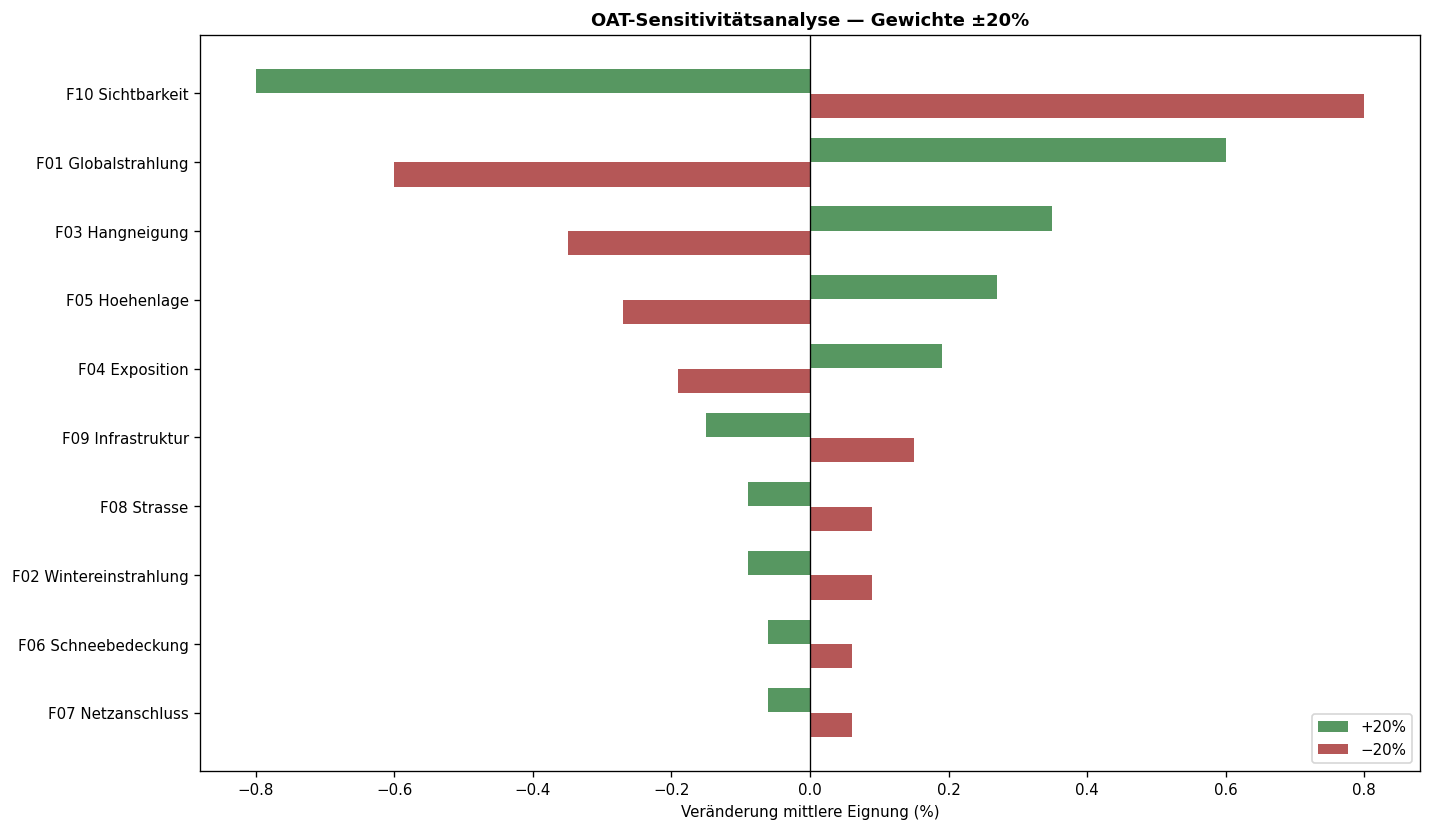

In [13]:
# Tornado-Diagramm
plot_df = df_oat.copy()
plot_df['criterion'] = plot_df['criterion'].str.replace('_', ' ').str.replace('f0', 'F0')
plot_df['abs_change'] = plot_df['change_pct'].abs()
order = plot_df.groupby('criterion')['abs_change'].max().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(12, 7))
for i, crit in enumerate(order):
    row_plus = plot_df[(plot_df['criterion'] == crit) & (plot_df['direction'].str.startswith('+'))].iloc[0]
    row_minus = plot_df[(plot_df['criterion'] == crit) & (plot_df['direction'].str.startswith('-'))].iloc[0]
    ax.barh(i + 0.18, row_plus['change_pct'], height=0.35, color='#2D7D3A', alpha=0.8, label='+20%' if i == 0 else '')
    ax.barh(i - 0.18, row_minus['change_pct'], height=0.35, color='#A32D2D', alpha=0.8, label='−20%' if i == 0 else '')
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=9)
ax.set_xlabel('Veränderung mittlere Eignung (%)')
ax.set_title('OAT-Sensitivitätsanalyse — Gewichte ±20%', fontweight='bold')
ax.axvline(0, color='black', lw=0.8)
ax.legend(loc='lower right')
plt.tight_layout()
fig.savefig(OUT_F / 'oat_tornado.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Zusammenfassung

In [14]:
summary_records = [
    {'Test': 'Hit Rate positiv', 'Wert': f'{hit_count}/{len(positive)}', 'Interpretation': 'Mehrheit der geplanten Standorte innerhalb geeigneter Fläche' if hit_rate >= 50 else 'Tiefe Trefferquote bei geplanten Standorten'},
    {'Test': 'Mann-Whitney U', 'Wert': f'U={u_stat:.1f}, p={p_value:.4g}', 'Interpretation': 'Standorte sind signifikant höher' if p_value < 0.05 else 'Kein signifikanter Unterschied'},
    {'Test': 'Kruskal-Wallis', 'Wert': f'H={h_stat:.3f}, p={p_kw:.4g}', 'Interpretation': 'Statusgruppen unterscheiden sich signifikant' if p_kw < 0.05 else 'Keine signifikanten Unterschiede zwischen Statusgruppen'},
]
df_summary = pd.DataFrame(summary_records)
df_summary.to_csv(OUT_T / 'validation_summary.csv', index=False)
print(df_summary.to_string(index=False))
print(f'\nOutputs: {OUT_F / "validation_hitrate.png"}, {OUT_F / "validation_mannwhitney.png"}, {OUT_F / "oat_tornado.png"}, {OUT_T / "validation_summary.csv"}, {OUT_T / "validation_point_detail.csv"}, {OUT_T / "oat_sensitivity.csv"}')


            Test             Wert                                          Interpretation
Hit Rate positiv             5/13             Tiefe Trefferquote bei geplanten Standorten
  Mann-Whitney U    U=4518.0, p=1                          Kein signifikanter Unterschied
  Kruskal-Wallis H=3.626, p=0.459 Keine signifikanten Unterschiede zwischen Statusgruppen

Outputs: ..\projekt_final\outputs\figures\validation_hitrate.png, ..\projekt_final\outputs\figures\validation_mannwhitney.png, ..\projekt_final\outputs\figures\oat_tornado.png, ..\projekt_final\outputs\tables\validation_summary.csv, ..\projekt_final\outputs\tables\validation_point_detail.csv, ..\projekt_final\outputs\tables\oat_sensitivity.csv


## Ergebnis

**Validierung:**
- Hit Rate zeigt, wie viele realisierte und geplante Standorte im geeigneten Bereich liegen.
- Mann-Whitney U prüft, ob Standort-Werte systematisch höher sind als zufällige Constraint-Pixel.
- Kruskal-Wallis testet Unterschiedlichkeit der Eignungswerte zwischen Statusgruppen.

**Sensitivität:**
- OAT identifiziert die Kriterien mit dem grössten Einfluss auf die mittlere Eignung.
- Die Ergebnisse zeigen, welche Gewichtungen stabil bzw. sensibel sind.

**Einschränkungen:**
- Nur 22 Standorte; keine repräsentative Stichprobe.
- Punktbasierte Standortwerte sind eine Annäherung an polygonale Referenzen.
- Ergebnisse gelten für die aktuellen Constraint- und Gewichtungsannahmen.
